In [2]:
import numpy as np
from numpy import *
import matplotlib.pyplot as plt
from dPCA import dPCA
from mpl_toolkits.mplot3d import Axes3D
from numpy.random import rand, randn, randint

# Use dPCA on Rowland's 23 data

## Import the data

In [3]:
def load_rowland_sessions(npz_path):
    """Load sessions from the exported .npz file."""
    data = np.load(npz_path, allow_pickle=True)
    session_ids = data['session_ids']
    
    sessions = {}
    for sid in session_ids:
        prefix = f"session_{sid}_"
        sessions[sid] = {
            'signature': str(data[f'{prefix}signature']),
            'mouse': str(data[f'{prefix}mouse']),
            'run_number': int(data[f'{prefix}run_number']),
            'name': str(data[f'{prefix}name']),
            'filter_ps_time': data[f'{prefix}filter_ps_time'],
            'behaviour_trials': data[f'{prefix}behaviour_trials'],
            'is_target': data[f'{prefix}is_target'],
            'trial_subsets': data[f'{prefix}trial_subsets'],
            'n_cells': int(data[f'{prefix}n_cells']),
            'n_trials': int(data[f'{prefix}n_trials']),
            'n_times': int(data[f'{prefix}n_times']),
            's1_bool': data[f'{prefix}s1_bool'],
            's2_bool': data[f'{prefix}s2_bool'],
            'outcome': data[f'{prefix}outcome'],
            'frequency': float(data[f'{prefix}frequency']),
        }
    return sessions

sessions = load_rowland_sessions('/home/patriciobarber/AdaptiveLatents/workspace/datasets/rowland23/all_sessions.npz')

In [4]:
s0 = sessions[0]

# dPCA (Demixed Principal Component Analysis) on Session 0

## What is dPCA?

**dPCA** is a dimensionality reduction technique designed for neural data with multiple experimental parameters (e.g., stimulus type, time, decision). Unlike standard PCA which finds components that maximize total variance, dPCA finds components that **demix** variance into interpretable parts.

### The Math

Given neural data $X_{n,st}$ where:
- $n$ = neuron index (1 to N)
- $s$ = stimulus condition (1 to S)  
- $t$ = time bin (1 to T)

**Standard PCA** decomposes the data as:
$$X = FD$$
where $F$ is the encoder matrix and $D$ is the decoder matrix.

**dPCA** instead decomposes the data by marginalizations:
$$X = X_t + X_s + X_{st} + X_{noise}$$

where:
- $X_t$ = time-dependent component (averaged over stimuli)
- $X_s$ = stimulus-dependent component (averaged over time)  
- $X_{st}$ = stimulus-time interaction
- $X_{noise}$ = residual

For each marginalization $\phi$, dPCA finds:
$$X_\phi = F_\phi D_\phi$$

### Key Insight
dPCA answers: "How much variance is explained by time alone? By stimulus alone? By their interaction?"

## Step 1: Explore Session 0 Data Structure

In [6]:
# Extract key information from session 0
s0 = sessions[0]

print("=" * 60)
print("SESSION 0 DATA STRUCTURE")
print("=" * 60)

# Neural data dimensions
neural_data = s0['behaviour_trials']  # (n_cells, n_trials, n_times)
N = s0['n_cells']      # Number of neurons
n_trials = s0['n_trials']  # Total number of trials
T = s0['n_times']      # Number of time points

print(f"\n📊 NEURAL DATA DIMENSIONS:")
print(f"   • Number of neurons (N): {N}")
print(f"   • Number of trials: {n_trials}")
print(f"   • Number of time points (T): {T}")
print(f"   • Neural data shape: {neural_data.shape}")

# Time information
time_array = s0['filter_ps_time']
print(f"\n⏱️ TIME INFO:")
print(f"   • Time range: {time_array[0]:.3f}s to {time_array[-1]:.3f}s")
print(f"   • Sampling frequency: {s0['frequency']} Hz")

# Stimulus conditions - number of cells stimulated per trial
trial_subsets = s0['trial_subsets']
unique_stim_conditions = np.unique(trial_subsets)
print(f"\n🔦 STIMULUS CONDITIONS (# cells stimulated):")
print(f"   • Unique conditions: {unique_stim_conditions}")
for n_stim in unique_stim_conditions:
    count = np.sum(trial_subsets == n_stim)
    print(f"   • {n_stim} cells stimulated: {count} trials")

# Behavioral outcomes
print(f"\n🎯 BEHAVIORAL OUTCOMES:")
for outcome in np.unique(s0['outcome']):
    count = np.sum(s0['outcome'] == outcome)
    print(f"   • {outcome}: {count} trials")

SESSION 0 DATA STRUCTURE

📊 NEURAL DATA DIMENSIONS:
   • Number of neurons (N): 471
   • Number of trials: 162
   • Number of time points (T): 420
   • Neural data shape: (471, 162, 420)

⏱️ TIME INFO:
   • Time range: -7.967s to 6.000s
   • Sampling frequency: 30.0 Hz

🔦 STIMULUS CONDITIONS (# cells stimulated):
   • Unique conditions: [  0   5  10  20  30  40  50 150]
   • 0 cells stimulated: 61 trials
   • 5 cells stimulated: 9 trials
   • 10 cells stimulated: 8 trials
   • 20 cells stimulated: 7 trials
   • 30 cells stimulated: 13 trials
   • 40 cells stimulated: 8 trials
   • 50 cells stimulated: 9 trials
   • 150 cells stimulated: 47 trials

🎯 BEHAVIORAL OUTCOMES:
   • arm: 2 trials
   • cr: 31 trials
   • fp: 28 trials
   • hit: 79 trials
   • miss: 16 trials
   • urh: 6 trials


## Step 2: Prepare Data for dPCA

dPCA requires data in a specific format:
- **Trial-averaged data**: `R` with shape `(N neurons, S conditions, T timepoints)`
- **Trial-by-trial data**: `trialR` with shape `(n_trials_per_condition, N, S, T)` - needed for regularization

We'll use the **number of stimulated cells** as our stimulus condition (0, 5, 10, 20, 40 cells).

In [5]:
# Prepare data for dPCA
# We'll use stimulus condition = number of cells stimulated

neural_data = s0['behaviour_trials']  # (n_cells, n_trials, n_times)
trial_subsets = s0['trial_subsets']   # number of cells stimulated per trial
unique_conditions = np.unique(trial_subsets)

N = s0['n_cells']
T = s0['n_times']
S = len(unique_conditions)  # number of stimulus conditions

print(f"dPCA Data Preparation:")
print(f"  N (neurons) = {N}")
print(f"  S (stimulus conditions) = {S}")
print(f"  T (timepoints) = {T}")
print(f"  Conditions: {unique_conditions}")

# Find minimum number of trials per condition (for balanced design)
trials_per_condition = {cond: np.where(trial_subsets == cond)[0] for cond in unique_conditions}
min_trials = min([len(trials) for trials in trials_per_condition.values()])

print(f"\n  Trials per condition:")
for cond, trials in trials_per_condition.items():
    print(f"    {cond} cells: {len(trials)} trials")
print(f"\n  Using {min_trials} trials per condition (balanced design)")

# Build trial-by-trial data: (n_trials, N, S, T)
trialR = np.zeros((min_trials, N, S, T))

for s_idx, cond in enumerate(unique_conditions):
    trial_indices = trials_per_condition[cond][:min_trials]
    for trial_idx, t_idx in enumerate(trial_indices):
        trialR[trial_idx, :, s_idx, :] = neural_data[:, t_idx, :]

# Trial-averaged data: (N, S, T)
R = np.mean(trialR, axis=0)

# Center the data (subtract mean across all conditions and times for each neuron)
R_centered = R - np.mean(R.reshape((N, -1)), axis=1)[:, None, None]

print(f"\n✅ Data shapes:")
print(f"   Trial-averaged R: {R.shape} (N, S, T)")
print(f"   Trial-by-trial trialR: {trialR.shape} (n_trials, N, S, T)")
print(f"   Centered R: {R_centered.shape}")

dPCA Data Preparation:
  N (neurons) = 471
  S (stimulus conditions) = 8
  T (timepoints) = 420
  Conditions: [  0   5  10  20  30  40  50 150]

  Trials per condition:
    0 cells: 61 trials
    5 cells: 9 trials
    10 cells: 8 trials
    20 cells: 7 trials
    30 cells: 13 trials
    40 cells: 8 trials
    50 cells: 9 trials
    150 cells: 47 trials

  Using 7 trials per condition (balanced design)

✅ Data shapes:
   Trial-averaged R: (471, 8, 420) (N, S, T)
   Trial-by-trial trialR: (7, 471, 8, 420) (n_trials, N, S, T)
   Centered R: (471, 8, 420)


## Step 3: Fit dPCA Model

Key parameters:
- `labels='st'`: We have **s**timulus and **t**ime as our two parameter axes
- `regularizer='auto'`: Automatically optimize regularization to prevent overfitting
- `n_components`: Number of components per marginalization

### Regularization and Overfitting

dPCA uses **ridge regularization** to prevent overfitting:
$$\hat{D} = \arg\min_D \|X - FD\|^2 + \lambda \|D\|^2$$

When `regularizer='auto'`, it uses cross-validation on the trial-by-trial data to find optimal $\lambda$.

In [6]:
# Fit dPCA model
# Labels: 's' = stimulus (# cells stimulated), 't' = time

dpca = dPCA.dPCA(labels='st', regularizer='auto', n_components=5)
dpca.protect = ['t']  # Protect time components from regularization mixing

print("Fitting dPCA model...")
print("  This uses cross-validation to find optimal regularization...")

# Fit and transform
Z = dpca.fit_transform(R_centered, trialR)

print("\n✅ dPCA fitting complete!")
print(f"\nExtracted component keys: {list(Z.keys())}")
print("  't'  = Time components (stimulus-averaged)")
print("  's'  = Stimulus components (time-averaged)")  
print("  'st' = Stimulus-time interaction components")

for key in Z.keys():
    print(f"\n  Z['{key}'] shape: {Z[key].shape}")

You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Fitting dPCA model...
  This uses cross-validation to find optimal regularization...
Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.0008819763977946266
Regularization will be fixed; to compute the optimal                    parameter agai

## Step 4: Variance Explained Analysis

This is crucial for understanding:
1. **Total variance explained** by dPCA vs standard PCA
2. **Demixed variance**: How much is due to time, stimulus, or interaction?
3. **Overfitting detection**: Compare train vs test (cross-validated) performance

In [11]:
# ============================================================
# VARIANCE EXPLAINED ANALYSIS
# ============================================================
import builtins  # Use Python's built-in min/max

print("=" * 70)
print("VARIANCE EXPLAINED BY dPCA")
print("=" * 70)

# Get explained variance ratios per marginalization
if hasattr(dpca, 'explained_variance_ratio_'):
    print("\n📊 EXPLAINED VARIANCE BY MARGINALIZATION:")
    print("-" * 50)
    
    total_var_explained = 0
    marginalization_labels = {'t': 'Time', 's': 'Stimulus', 'st': 'Interaction'}
    
    for key in dpca.explained_variance_ratio_.keys():
        var_ratios = dpca.explained_variance_ratio_[key]
        total_for_marg = np.sum(var_ratios) * 100
        total_var_explained += total_for_marg
        
        label = marginalization_labels.get(key, key)
        print(f"\n  {label} ('{key}'):")
        print(f"    Total: {total_for_marg:.2f}%")
        for i, v in enumerate(var_ratios):
            print(f"    Component {i+1}: {v*100:.2f}%")
    
    print(f"\n{'=' * 50}")
    print(f"  TOTAL VARIANCE EXPLAINED: {total_var_explained:.2f}%")
    print(f"{'=' * 50}")

# Compare with standard PCA
from sklearn.decomposition import PCA

# Reshape for standard PCA: (N, S*T) -> transpose -> (S*T, N)
X_for_pca = R_centered.reshape(N, -1).T
n_components_pca = builtins.min(15, N)
pca = PCA(n_components=n_components_pca)
pca.fit(X_for_pca)

print("\n\n📊 COMPARISON WITH STANDARD PCA:")
print("-" * 50)
print(f"  PCA Top {n_components_pca} components explain: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")
print(f"  dPCA Total (all marginalizations): {total_var_explained:.2f}%")

# Cumulative variance
print("\n  PCA cumulative variance:")
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
for i in [0, 2, 4, 9, 14]:
    if i < len(cumvar):
        print(f"    Top {i+1} PCs: {cumvar[i]:.2f}%")

VARIANCE EXPLAINED BY dPCA

📊 EXPLAINED VARIANCE BY MARGINALIZATION:
--------------------------------------------------

  Stimulus ('s'):
    Total: 23.15%
    Component 1: 20.58%
    Component 2: 1.65%
    Component 3: 0.47%
    Component 4: 0.31%
    Component 5: 0.15%

  Time ('t'):
    Total: 2.00%
    Component 1: 1.52%
    Component 2: 0.29%
    Component 3: 0.19%
    Component 4: 0.00%
    Component 5: 0.00%

  Interaction ('st'):
    Total: 1.36%
    Component 1: 0.74%
    Component 2: 0.43%
    Component 3: 0.14%
    Component 4: 0.03%
    Component 5: 0.02%

  TOTAL VARIANCE EXPLAINED: 26.52%


📊 COMPARISON WITH STANDARD PCA:
--------------------------------------------------
  PCA Top 15 components explain: 70.02%
  dPCA Total (all marginalizations): 26.52%

  PCA cumulative variance:
    Top 1 PCs: 29.76%
    Top 3 PCs: 46.36%
    Top 5 PCs: 56.45%
    Top 10 PCs: 65.59%
    Top 15 PCs: 70.02%


## Step 5: Overfitting Analysis

To detect overfitting, we:
1. **Cross-validate**: Hold out trials and measure reconstruction error
2. **Compare train vs test**: Large gap = overfitting
3. **Check regularization**: Higher λ = more regularization (less overfitting risk)

In [13]:
# ============================================================
# OVERFITTING ANALYSIS
# ============================================================
import builtins

print("=" * 70)
print("OVERFITTING ANALYSIS")
print("=" * 70)

# Check if regularization was used
if hasattr(dpca, 'regularizer'):
    print(f"\n🔧 REGULARIZATION:")
    print(f"   Optimal lambda (from auto-search): {dpca.regularizer:.6f}")
    print(f"   Higher lambda = more regularization = less overfitting risk")

# Manual cross-validation to check overfitting
from sklearn.model_selection import KFold

print("\n📊 CROSS-VALIDATION ANALYSIS:")
print("-" * 50)

# We'll do leave-one-out on trials
n_folds = builtins.min(5, min_trials)
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

train_errors = []
test_errors = []

for fold, (train_idx, test_idx) in enumerate(kf.split(range(min_trials))):
    # Split trials
    train_trials = trialR[train_idx]
    test_trials = trialR[test_idx]
    
    # Average training trials
    R_train = np.mean(train_trials, axis=0)
    R_train_centered = R_train - np.mean(R_train.reshape(N, -1), axis=1)[:, None, None]
    
    # Average test trials
    R_test = np.mean(test_trials, axis=0)
    R_test_centered = R_test - np.mean(R_test.reshape(N, -1), axis=1)[:, None, None]
    
    # Fit dPCA on training data
    dpca_cv = dPCA.dPCA(labels='st', regularizer='auto', n_components=5)
    dpca_cv.protect = ['t']
    
    try:
        Z_train = dpca_cv.fit_transform(R_train_centered, train_trials)
        
        # Reconstruct training data
        R_train_recon = np.zeros_like(R_train_centered)
        for key in Z_train.keys():
            # Reconstruct each marginalization
            D = dpca_cv.D[key]  # Decoder
            R_train_recon += np.tensordot(D.T, Z_train[key], axes=(1, 0))
        
        # Project test data
        Z_test = dpca_cv.transform(R_test_centered)
        
        # Reconstruct test data
        R_test_recon = np.zeros_like(R_test_centered)
        for key in Z_test.keys():
            D = dpca_cv.D[key]
            R_test_recon += np.tensordot(D.T, Z_test[key], axes=(1, 0))
        
        # Compute errors (normalized MSE)
        train_mse = np.mean((R_train_centered - R_train_recon) ** 2)
        test_mse = np.mean((R_test_centered - R_test_recon) ** 2)
        
        train_var = np.var(R_train_centered)
        test_var = np.var(R_test_centered)
        
        train_errors.append(train_mse / train_var)
        test_errors.append(test_mse / test_var)
        
    except Exception as e:
        print(f"   Fold {fold+1}: Error - {e}")
        continue

if train_errors:
    mean_train_error = np.mean(train_errors)
    mean_test_error = np.mean(test_errors)
    
    print(f"\n   Train reconstruction error: {mean_train_error:.4f} (lower is better)")
    print(f"   Test reconstruction error:  {mean_test_error:.4f}")
    print(f"   Generalization gap: {mean_test_error - mean_train_error:.4f}")
    
    # Interpretation
    gap = mean_test_error - mean_train_error
    print(f"\n🎯 INTERPRETATION:")
    if gap < 0.1:
        print(f"   ✅ Low generalization gap ({gap:.4f}) - NO significant overfitting")
    elif gap < 0.3:
        print(f"   ⚠️  Moderate generalization gap ({gap:.4f}) - Some overfitting possible")
    else:
        print(f"   ❌ High generalization gap ({gap:.4f}) - OVERFITTING detected!")
        print(f"      Consider: more regularization, fewer components, or more trials")

OVERFITTING ANALYSIS

🔧 REGULARIZATION:
   Optimal lambda (from auto-search): 0.000882
   Higher lambda = more regularization = less overfitting risk

📊 CROSS-VALIDATION ANALYSIS:
--------------------------------------------------
You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.0006

## Step 6: Visualize dPCA Components

Plot the demixed components to understand neural dynamics:

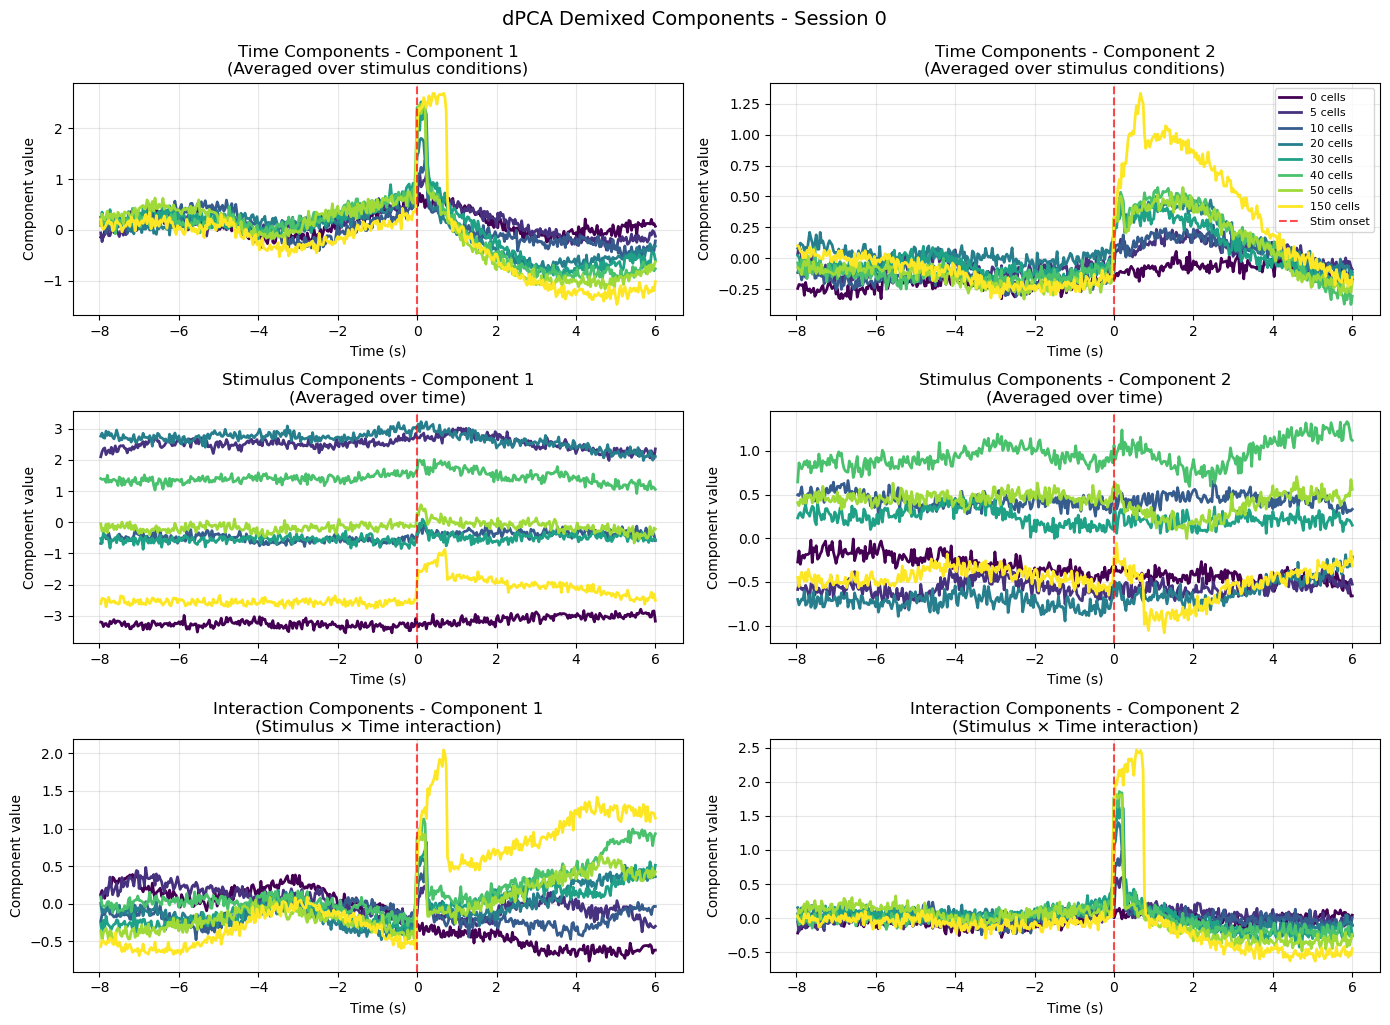


📊 Variance explained by plotted components:
  Time Components:
    Component 1: 1.52%
    Component 2: 0.29%
  Stimulus Components:
    Component 1: 20.58%
    Component 2: 1.65%
  Interaction Components:
    Component 1: 0.74%
    Component 2: 0.43%


In [15]:
# ============================================================
# VISUALIZE dPCA COMPONENTS
# ============================================================
import builtins

time_array = s0['filter_ps_time']
stim_onset_idx = np.argmin(np.abs(time_array))  # t=0

# Color palette for stimulus conditions
colors = plt.cm.viridis(np.linspace(0, 1, S))
condition_labels = [f'{int(c)} cells' for c in unique_conditions]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

marginalization_info = {
    't': ('Time Components', 'Averaged over stimulus conditions'),
    's': ('Stimulus Components', 'Averaged over time'),
    'st': ('Interaction Components', 'Stimulus × Time interaction')
}

for row, key in enumerate(['t', 's', 'st']):
    if key not in Z:
        continue
        
    title, subtitle = marginalization_info[key]
    
    # Plot first two components
    for col in range(2):
        ax = axes[row, col]
        
        if col < Z[key].shape[0]:
            for s_idx in range(S):
                ax.plot(time_array, Z[key][col, s_idx, :], 
                       color=colors[s_idx], linewidth=2, label=condition_labels[s_idx])
            
            # Mark stimulation onset
            ax.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Stim onset')
            
            ax.set_xlabel('Time (s)')
            ax.set_ylabel('Component value')
            ax.set_title(f"{title} - Component {col+1}\n({subtitle})")
            ax.grid(True, alpha=0.3)
            
            if row == 0 and col == 1:
                ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.suptitle('dPCA Demixed Components - Session 0', fontsize=14, y=1.02)
plt.show()

# Print variance for each plotted component
print("\n📊 Variance explained by plotted components:")
for key in ['t', 's', 'st']:
    if key in dpca.explained_variance_ratio_:
        var = dpca.explained_variance_ratio_[key]
        label = marginalization_info[key][0]
        print(f"  {label}:")
        n_to_show = builtins.min(2, len(var))
        for i in range(n_to_show):
            print(f"    Component {i+1}: {var[i]*100:.2f}%")

## Step 7: Summary Statistics and Interpretation

dPCA ANALYSIS SUMMARY - SESSION 0

📋 DATA OVERVIEW:
   Neurons: 471
   Stimulus conditions: 8 ([0, 5, 10, 20, 30, 40, 50, 150] cells stimulated)
   Time points: 420
   Trials per condition: 7

📊 VARIANCE DECOMPOSITION:
   Time components ('t'):          2.00% (  7.6% of explained)
   Stimulus components ('s'):     23.15% ( 87.3% of explained)
   Interaction ('st'):             1.36% (  5.1% of explained)
   ─────────────────────────────────────
   TOTAL EXPLAINED:               26.52%

🎯 INTERPRETATION:
   Dominant source of variance: STIMULUS
   ✅ Stimulus condition (# cells stimulated) explains 23.1% of variance
      → Neural activity differs based on stimulation intensity!


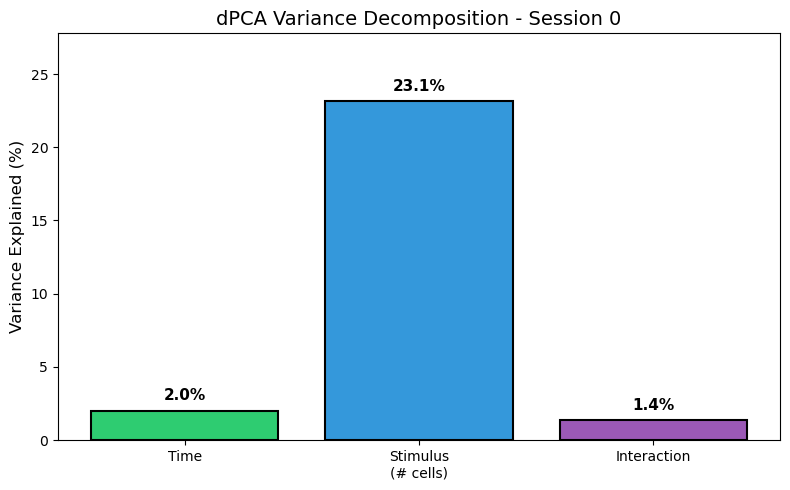

In [17]:
# ============================================================
# SUMMARY STATISTICS
# ============================================================
import builtins

print("=" * 70)
print("dPCA ANALYSIS SUMMARY - SESSION 0")
print("=" * 70)

print(f"\n📋 DATA OVERVIEW:")
print(f"   Neurons: {N}")
print(f"   Stimulus conditions: {S} ({[int(c) for c in unique_conditions]} cells stimulated)")
print(f"   Time points: {T}")
print(f"   Trials per condition: {min_trials}")

print(f"\n📊 VARIANCE DECOMPOSITION:")
var_by_marg = {}
for key in dpca.explained_variance_ratio_.keys():
    var_by_marg[key] = np.sum(dpca.explained_variance_ratio_[key]) * 100

total_var = builtins.sum(var_by_marg.values())
print(f"   Time components ('t'):        {var_by_marg.get('t', 0):6.2f}% ({var_by_marg.get('t', 0)/total_var*100:5.1f}% of explained)")
print(f"   Stimulus components ('s'):    {var_by_marg.get('s', 0):6.2f}% ({var_by_marg.get('s', 0)/total_var*100:5.1f}% of explained)")
print(f"   Interaction ('st'):           {var_by_marg.get('st', 0):6.2f}% ({var_by_marg.get('st', 0)/total_var*100:5.1f}% of explained)")
print(f"   ─────────────────────────────────────")
print(f"   TOTAL EXPLAINED:              {total_var:6.2f}%")

print(f"\n🎯 INTERPRETATION:")
dominant = builtins.max(var_by_marg, key=var_by_marg.get)
dominant_labels = {'t': 'TIME', 's': 'STIMULUS', 'st': 'INTERACTION'}
print(f"   Dominant source of variance: {dominant_labels[dominant]}")

if var_by_marg.get('s', 0) > 5:
    print(f"   ✅ Stimulus condition (# cells stimulated) explains {var_by_marg.get('s', 0):.1f}% of variance")
    print(f"      → Neural activity differs based on stimulation intensity!")
else:
    print(f"   ⚠️  Stimulus condition explains only {var_by_marg.get('s', 0):.1f}% of variance")
    print(f"      → Limited effect of stimulation intensity on population activity")

if var_by_marg.get('st', 0) > 5:
    print(f"   ✅ Stimulus×Time interaction explains {var_by_marg.get('st', 0):.1f}% of variance")
    print(f"      → Different stimulation intensities produce different temporal dynamics!")

# Bar chart summary
fig, ax = plt.subplots(figsize=(8, 5))
keys = ['t', 's', 'st']
labels = ['Time', 'Stimulus\n(# cells)', 'Interaction']
values = [var_by_marg.get(k, 0) for k in keys]
colors_bar = ['#2ecc71', '#3498db', '#9b59b6']

bars = ax.bar(labels, values, color=colors_bar, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Variance Explained (%)', fontsize=12)
ax.set_title('dPCA Variance Decomposition - Session 0', fontsize=14)
ax.set_ylim(0, builtins.max(values) * 1.2)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 8: Project Trials 16 and 17 into dPCA Space

Plot specific trials in the dPCA component space with markers for:
- ● Start of trial
- ★ Stim onset (t=0)
- ■ End of trial
- ◆ Stimulation timepoints

In [19]:
# ============================================================
# PROJECT TRIALS 16 AND 17 INTO dPCA SPACE
# ============================================================
from scipy.ndimage import gaussian_filter1d
import builtins

# Trials to plot
trial_indices_to_plot = [16, 17]

# Get data
neural_data = s0['behaviour_trials']  # (n_cells, n_trials, n_times)
is_target = s0['is_target']  # (n_cells, n_trials, n_times)
time_array = s0['filter_ps_time']
trial_subsets = s0['trial_subsets']

# Find the photostim onset index (t=0)
stim_onset_idx = np.argmin(np.abs(time_array))
print(f"Photostim onset at index {stim_onset_idx} (t = {time_array[stim_onset_idx]:.3f}s)")

# Get stimulation timepoints for trials 16 and 17
stim_timepoints = {}
for trial_idx in trial_indices_to_plot:
    # Find timepoints where any cell was stimulated
    stim_frames = np.where(is_target[:, trial_idx, :].any(axis=0))[0]
    stim_timepoints[trial_idx] = stim_frames
    targeted_neurons = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
    n_stim = trial_subsets[trial_idx]
    print(f"Trial {trial_idx}: {len(targeted_neurons)} neurons targeted (expected {n_stim}), {len(stim_frames)} stim timepoints")

# Check the shape of the encoder matrices
print(f"\nEncoder matrix shapes:")
for key in dpca.P.keys():
    print(f"  P['{key}']: {dpca.P[key].shape}")

# Project individual trials into dPCA space
# dPCA encoder P has shape (n_neurons, n_components)
# So projection is: z = trial_data.T @ P  =>  (n_times, n_components)

sigma = 3  # Smoothing parameter

# Store trajectories for each marginalization
trajectories_dpca = {key: {} for key in Z.keys()}
trajectories_dpca_smooth = {key: {} for key in Z.keys()}

for trial_idx in trial_indices_to_plot:
    # Get trial data: (n_cells, n_times)
    trial_data = neural_data[:, trial_idx, :]
    
    # Center the trial data (same centering as used for dPCA fitting)
    trial_centered = trial_data - np.mean(trial_data, axis=1, keepdims=True)
    
    # Project into each dPCA marginalization
    for key in Z.keys():
        # Get encoder matrix P for this marginalization
        P = dpca.P[key]  # Encoder: (n_neurons, n_components)
        
        # Project: trial_centered.T @ P => (n_times, n_neurons) @ (n_neurons, n_components) => (n_times, n_components)
        z_proj = trial_centered.T @ P
        
        trajectories_dpca[key][trial_idx] = z_proj  # (n_times, n_components)
        
        # Smooth each component
        z_smooth = np.zeros_like(z_proj)
        for dim in range(z_proj.shape[1]):
            z_smooth[:, dim] = gaussian_filter1d(z_proj[:, dim], sigma=sigma)
        trajectories_dpca_smooth[key][trial_idx] = z_smooth

print(f"\n✅ Projected trials {trial_indices_to_plot} into dPCA space")
for key in Z.keys():
    print(f"   Z['{key}'] trajectory shape: {trajectories_dpca_smooth[key][trial_indices_to_plot[0]].shape}")

Photostim onset at index 239 (t = 0.000s)
Trial 16: 0 neurons targeted (expected 0), 0 stim timepoints
Trial 17: 177 neurons targeted (expected 150), 420 stim timepoints

Encoder matrix shapes:
  P['s']: (471, 5)
  P['t']: (471, 5)
  P['st']: (471, 5)

✅ Projected trials [16, 17] into dPCA space
   Z['s'] trajectory shape: (420, 5)
   Z['t'] trajectory shape: (420, 5)
   Z['st'] trajectory shape: (420, 5)


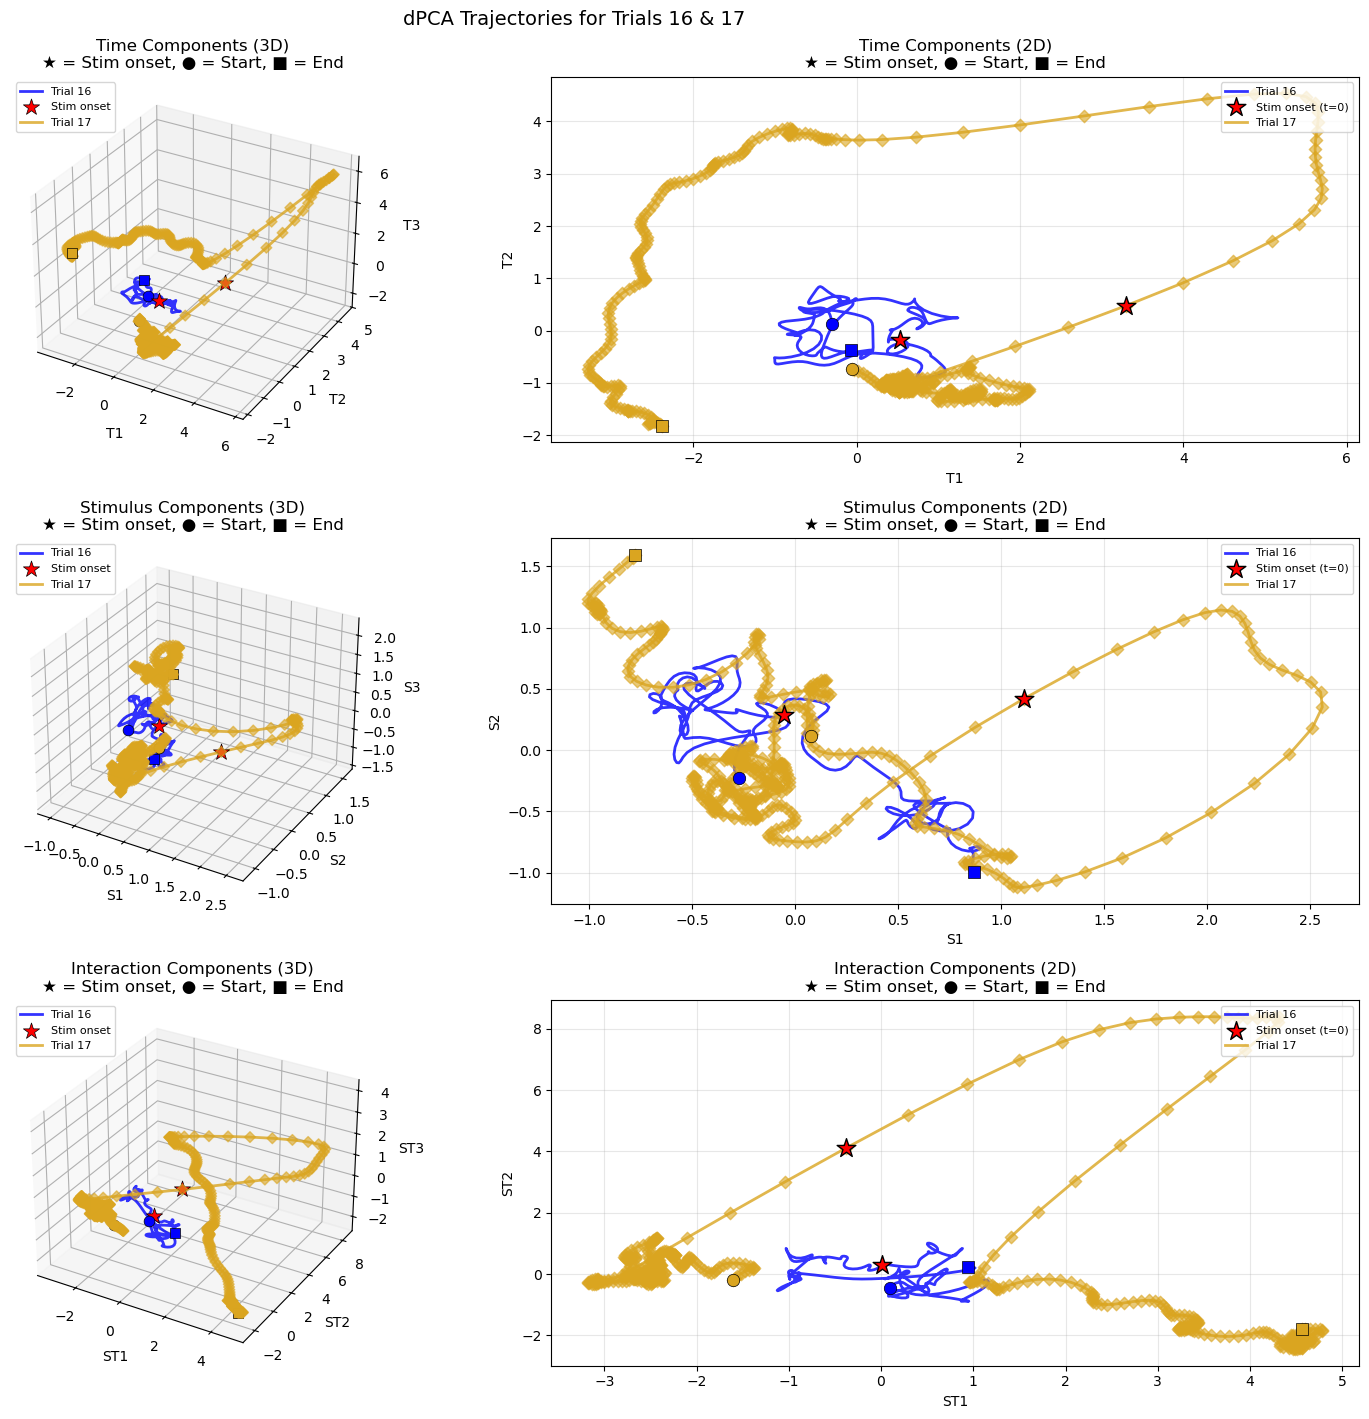


📋 TRIAL INFORMATION:
   Trial 16: 0 cells stimulated, outcome: cr
   Trial 17: 150 cells stimulated, outcome: hit


In [21]:
# ============================================================
# PLOT dPCA TRAJECTORIES FOR TRIALS 16 AND 17
# ============================================================

# Create figure with 3 rows (Time, Stimulus, Interaction) x 2 columns (3D, 2D)
fig = plt.figure(figsize=(16, 14))

# Colors for trajectories
colors = ['blue', 'goldenrod']
marginalization_titles = {'t': 'Time Components', 's': 'Stimulus Components', 'st': 'Interaction Components'}

for row_idx, key in enumerate(['t', 's', 'st']):
    if key not in Z:
        continue
    
    traj_data = trajectories_dpca_smooth[key]
    
    # 3D plot (left column) - use first 3 components
    ax3d = fig.add_subplot(3, 2, row_idx * 2 + 1, projection='3d')
    
    for i, trial_idx in enumerate(trial_indices_to_plot):
        traj = traj_data[trial_idx][:, :3]  # Use only first 3 components
        stim_frames = stim_timepoints[trial_idx]
        
        # Plot smoothed trajectory
        ax3d.plot(traj[:, 0], traj[:, 1], traj[:, 2], 
                 color=colors[i], alpha=0.8, linewidth=2, label=f'Trial {trial_idx}')
        
        # Mark stimulation timepoints (if any)
        if len(stim_frames) > 0:
            ax3d.scatter(traj[stim_frames, 0], traj[stim_frames, 1], traj[stim_frames, 2], 
                        color=colors[i], s=30, alpha=0.6, marker='D')
        
        # Mark photostim ONSET (t=0) with a red star
        ax3d.scatter(traj[stim_onset_idx, 0], traj[stim_onset_idx, 1], traj[stim_onset_idx, 2], 
                    color='red', marker='*', s=150, edgecolor='black', linewidth=0.5,
                    label='Stim onset' if i == 0 else '', zorder=10)
        
        # Mark start (circle) and end (square)
        ax3d.scatter(traj[0, 0], traj[0, 1], traj[0, 2], 
                    color=colors[i], marker='o', s=60, edgecolor='black', linewidth=0.5, zorder=5)
        ax3d.scatter(traj[-1, 0], traj[-1, 1], traj[-1, 2], 
                    color=colors[i], marker='s', s=60, edgecolor='black', linewidth=0.5, zorder=5)
    
    ax3d.set_xlabel(f'{key.upper()}1')
    ax3d.set_ylabel(f'{key.upper()}2')
    ax3d.set_zlabel(f'{key.upper()}3')
    ax3d.set_title(f'{marginalization_titles[key]} (3D)\n★ = Stim onset, ● = Start, ■ = End')
    ax3d.legend(loc='upper left', fontsize=8)
    
    # 2D plot (right column) - use first 2 components
    ax2d = fig.add_subplot(3, 2, row_idx * 2 + 2)
    
    for i, trial_idx in enumerate(trial_indices_to_plot):
        traj = traj_data[trial_idx][:, :2]  # Use only first 2 components
        stim_frames = stim_timepoints[trial_idx]
        
        # Plot smoothed trajectory
        ax2d.plot(traj[:, 0], traj[:, 1], color=colors[i], alpha=0.8, linewidth=2, label=f'Trial {trial_idx}')
        
        # Mark stimulation timepoints (if any)
        if len(stim_frames) > 0:
            ax2d.scatter(traj[stim_frames, 0], traj[stim_frames, 1], 
                        color=colors[i], s=40, alpha=0.6, marker='D', zorder=5)
        
        # Mark photostim ONSET (t=0) with a red star
        ax2d.scatter(traj[stim_onset_idx, 0], traj[stim_onset_idx, 1], 
                    color='red', marker='*', s=200, edgecolor='black', linewidth=1,
                    label='Stim onset (t=0)' if i == 0 else '', zorder=10)
        
        # Mark start (circle) and end (square)
        ax2d.scatter(traj[0, 0], traj[0, 1], color=colors[i], marker='o', s=80, edgecolor='black', linewidth=0.5, zorder=6)
        ax2d.scatter(traj[-1, 0], traj[-1, 1], color=colors[i], marker='s', s=80, edgecolor='black', linewidth=0.5, zorder=6)
    
    ax2d.set_xlabel(f'{key.upper()}1')
    ax2d.set_ylabel(f'{key.upper()}2')
    ax2d.set_title(f'{marginalization_titles[key]} (2D)\n★ = Stim onset, ● = Start, ■ = End')
    ax2d.legend(loc='upper right', fontsize=8)
    ax2d.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('dPCA Trajectories for Trials 16 & 17', fontsize=14, y=1.01)
plt.show()

# Print trial info
print("\n📋 TRIAL INFORMATION:")
for trial_idx in trial_indices_to_plot:
    outcome = s0['outcome'][trial_idx]
    n_stim = trial_subsets[trial_idx]
    print(f"   Trial {trial_idx}: {n_stim} cells stimulated, outcome: {outcome}")

## Step 9: Mixed Marginalization Plot (Time × Stimulus × Interaction)

The power of dPCA is that each component captures a **different type of variance**:
- **Time component**: What changes over time (averaged across stimuli)
- **Stimulus component**: What differs between stimulation intensities (averaged over time)
- **Interaction component**: How temporal dynamics differ by stimulus

We can plot the **top component from each marginalization** on different axes to see how these three aspects of neural activity relate to each other!

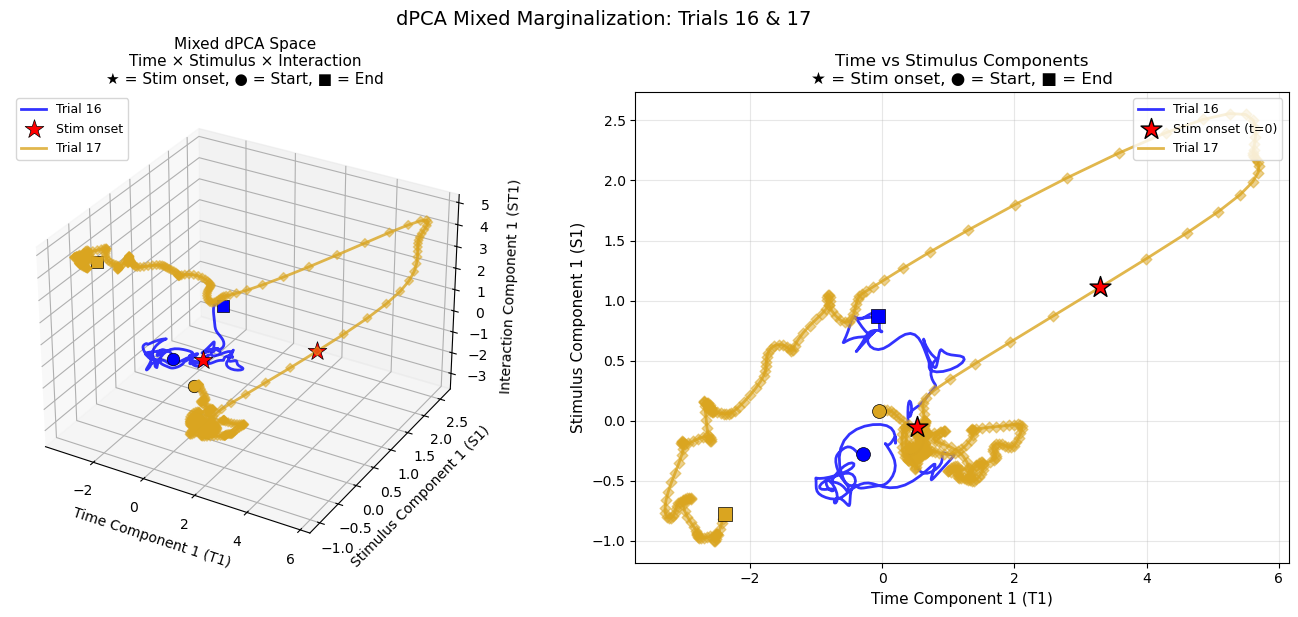


🎯 INTERPRETATION:
   • X-axis (T1): Captures general temporal dynamics (time-locked to trial)
   • Y-axis (S1): Captures effect of stimulation INTENSITY (# cells stimulated)
   • Z-axis (ST1): Captures how temporal dynamics DIFFER by stimulus condition

   Trial 16 (blue): 0 cells stimulated → stays near origin on S1 axis
   Trial 17 (gold): 150 cells stimulated → moves along S1 axis after stim onset


In [22]:
# ============================================================
# MIXED MARGINALIZATION PLOT: Time × Stimulus × Interaction
# ============================================================

# This combines the TOP component from each marginalization:
# X-axis: Time component 1 (T1) - captures temporal dynamics
# Y-axis: Stimulus component 1 (S1) - captures stimulus intensity effect
# Z-axis: Interaction component 1 (ST1) - captures stim-specific temporal patterns

fig = plt.figure(figsize=(14, 6))

# Colors for trajectories
colors = ['blue', 'goldenrod']

# ===== 3D PLOT =====
ax3d = fig.add_subplot(121, projection='3d')

for i, trial_idx in enumerate(trial_indices_to_plot):
    # Get top component from each marginalization (smoothed)
    t1 = trajectories_dpca_smooth['t'][trial_idx][:, 0]   # Time component 1
    s1 = trajectories_dpca_smooth['s'][trial_idx][:, 0]   # Stimulus component 1
    st1 = trajectories_dpca_smooth['st'][trial_idx][:, 0] # Interaction component 1
    
    stim_frames = stim_timepoints[trial_idx]
    
    # Plot trajectory
    ax3d.plot(t1, s1, st1, color=colors[i], alpha=0.8, linewidth=2, label=f'Trial {trial_idx}')
    
    # Mark stimulation timepoints (if any)
    if len(stim_frames) > 0:
        ax3d.scatter(t1[stim_frames], s1[stim_frames], st1[stim_frames], 
                    color=colors[i], s=20, alpha=0.5, marker='D')
    
    # Mark photostim ONSET (t=0) with red star
    ax3d.scatter(t1[stim_onset_idx], s1[stim_onset_idx], st1[stim_onset_idx], 
                color='red', marker='*', s=200, edgecolor='black', linewidth=0.5,
                label='Stim onset' if i == 0 else '', zorder=10)
    
    # Mark start (circle) and end (square)
    ax3d.scatter(t1[0], s1[0], st1[0], 
                color=colors[i], marker='o', s=80, edgecolor='black', linewidth=0.5, zorder=5)
    ax3d.scatter(t1[-1], s1[-1], st1[-1], 
                color=colors[i], marker='s', s=80, edgecolor='black', linewidth=0.5, zorder=5)

ax3d.set_xlabel('Time Component 1 (T1)', fontsize=10)
ax3d.set_ylabel('Stimulus Component 1 (S1)', fontsize=10)
ax3d.set_zlabel('Interaction Component 1 (ST1)', fontsize=10)
ax3d.set_title('Mixed dPCA Space\nTime × Stimulus × Interaction\n★ = Stim onset, ● = Start, ■ = End', fontsize=11)
ax3d.legend(loc='upper left', fontsize=9)

# ===== 2D PLOT (Time vs Stimulus) =====
ax2d = fig.add_subplot(122)

for i, trial_idx in enumerate(trial_indices_to_plot):
    t1 = trajectories_dpca_smooth['t'][trial_idx][:, 0]
    s1 = trajectories_dpca_smooth['s'][trial_idx][:, 0]
    stim_frames = stim_timepoints[trial_idx]
    
    # Plot trajectory
    ax2d.plot(t1, s1, color=colors[i], alpha=0.8, linewidth=2, label=f'Trial {trial_idx}')
    
    # Mark stimulation timepoints (if any)
    if len(stim_frames) > 0:
        ax2d.scatter(t1[stim_frames], s1[stim_frames], 
                    color=colors[i], s=30, alpha=0.5, marker='D', zorder=5)
    
    # Mark photostim ONSET (t=0) with red star
    ax2d.scatter(t1[stim_onset_idx], s1[stim_onset_idx], 
                color='red', marker='*', s=250, edgecolor='black', linewidth=1,
                label='Stim onset (t=0)' if i == 0 else '', zorder=10)
    
    # Mark start (circle) and end (square)
    ax2d.scatter(t1[0], s1[0], color=colors[i], marker='o', s=100, edgecolor='black', linewidth=0.5, zorder=6)
    ax2d.scatter(t1[-1], s1[-1], color=colors[i], marker='s', s=100, edgecolor='black', linewidth=0.5, zorder=6)

ax2d.set_xlabel('Time Component 1 (T1)', fontsize=11)
ax2d.set_ylabel('Stimulus Component 1 (S1)', fontsize=11)
ax2d.set_title('Time vs Stimulus Components\n★ = Stim onset, ● = Start, ■ = End', fontsize=12)
ax2d.legend(loc='upper right', fontsize=9)
ax2d.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('dPCA Mixed Marginalization: Trials 16 & 17', fontsize=14, y=1.02)
plt.show()

# Print interpretation
print("\n🎯 INTERPRETATION:")
print("   • X-axis (T1): Captures general temporal dynamics (time-locked to trial)")
print("   • Y-axis (S1): Captures effect of stimulation INTENSITY (# cells stimulated)")
print("   • Z-axis (ST1): Captures how temporal dynamics DIFFER by stimulus condition")
print("\n   Trial 16 (blue): 0 cells stimulated → stays near origin on S1 axis")
print("   Trial 17 (gold): 150 cells stimulated → moves along S1 axis after stim onset")

## Step 10: Shuffled Labels Cross-Validation (Proper Overfitting Test)

The standard way to test for overfitting in dPCA:

1. **Shuffle stimulus labels** across trials (break the true stimulus-neural relationship)
2. **Re-run dPCA** with shuffled labels  
3. **Compare variance**: If shuffled dPCA explains similar variance → **OVERFITTING**

**Key**: We must protect time (`protect=['t']`) because time points within a trial should never be shuffled.

In [10]:
# Proper shuffled-labels cross-validation with protect=['t']
from dPCA.dPCA import dPCA
import numpy as np

# Set number of shuffles
n_shuffles = 100

# Store results
true_var_t = []
true_var_s = []
true_var_st = []
shuffled_var_t = []
shuffled_var_s = []
shuffled_var_st = []

# Original labels - which condition each trial belongs to
# trialR has shape (n_trials_per_cond, n_neurons, n_conditions, n_times)
n_trials_per_cond = trialR.shape[0]
n_conditions = trialR.shape[2]
total_trials = n_trials_per_cond * n_conditions  # 7 * 8 = 56

# Create original label assignment (for reshuffling)
# Flatten to get all trials with their condition labels
original_labels = np.repeat(np.arange(n_conditions), n_trials_per_cond)

print(f"Total trials: {total_trials}")
print(f"Trials per condition: {n_trials_per_cond}")
print(f"Number of conditions: {n_conditions}")
print(f"Original labels shape: {original_labels.shape}")

# Fit true dPCA and get variance explained
dpca_true = dPCA(labels='st', regularizer='auto', n_components=5)
dpca_true.protect = ['t']  # CRITICAL: protect time dimension

# Fit on trial-averaged data
Z_true = dpca_true.fit_transform(R_centered, trialR)

# Get variance explained from the true fit
true_explained = dpca_true.explained_variance_ratio_
true_var_t_total = np.sum([true_explained[k] for k in true_explained if k[0] == 't'])
true_var_s_total = np.sum([true_explained[k] for k in true_explained if k[0] == 's'])
true_var_st_total = np.sum([true_explained[k] for k in true_explained if k[0:2] == 'st'])

print(f"\n=== TRUE dPCA Variance Explained ===")
print(f"Time (t): {true_var_t_total*100:.2f}%")
print(f"Stimulus (s): {true_var_s_total*100:.2f}%")  
print(f"Interaction (st): {true_var_st_total*100:.2f}%")

Total trials: 56
Trials per condition: 7
Number of conditions: 8
Original labels shape: (56,)
You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.0006299831412818761
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please          

In [12]:
# Now run shuffled labels test
# We shuffle which trials belong to which condition and re-run dPCA

shuffled_var_s_list = []
shuffled_var_t_list = []
shuffled_var_st_list = []

# Get the optimal regularizer from true fit
opt_lambda = dpca_true.regularizer

print(f"Running {n_shuffles} shuffled label iterations...")
print(f"(Using fixed regularization: {opt_lambda:.6f})")

for i in range(n_shuffles):
    if (i+1) % 20 == 0:
        print(f"  Iteration {i+1}/{n_shuffles}")
    
    # Shuffle trial labels
    shuffled_labels = np.random.permutation(original_labels)
    
    # Reconstruct trialR with shuffled assignments
    # We need to reassign trials to different conditions
    
    # First, flatten trials: shape (n_trials_per_cond, n_neurons, n_conditions, n_times) 
    # -> list of (n_neurons, n_times) for each trial
    all_trials = []
    for s in range(n_conditions):
        for k in range(n_trials_per_cond):
            all_trials.append(trialR[k, :, s, :])  # (n_neurons, n_times)
    
    # Now reassign based on shuffled labels
    # Count how many trials assigned to each condition
    trials_per_cond_shuffled = [np.sum(shuffled_labels == s) for s in range(n_conditions)]
    
    # Build shuffled trialR - need to handle unequal trial counts
    # For simplicity, we'll resample to keep balanced design
    trialR_shuffled = np.zeros((n_trials_per_cond, N, n_conditions, T))
    
    for s in range(n_conditions):
        cond_trials = np.where(shuffled_labels == s)[0]
        # If we don't have enough trials, resample with replacement
        if len(cond_trials) < n_trials_per_cond:
            cond_trials = np.random.choice(cond_trials, n_trials_per_cond, replace=True)
        else:
            cond_trials = cond_trials[:n_trials_per_cond]
        
        for k, trial_idx in enumerate(cond_trials):
            trialR_shuffled[k, :, s, :] = all_trials[trial_idx]
    
    # Compute trial-averaged data for shuffled
    R_shuffled = np.mean(trialR_shuffled, axis=0)
    
    # Mean center
    R_shuffled_centered = R_shuffled - np.mean(R_shuffled.reshape(N, -1), axis=1, keepdims=True).reshape(N, 1, 1)
    
    # Fit dPCA with FIXED regularization (use optimal from true fit for speed)
    dpca_shuff = dPCA(labels='st', regularizer=opt_lambda, n_components=5)
    dpca_shuff.protect = ['t']  # Still protect time!
    
    try:
        Z_shuff = dpca_shuff.fit_transform(R_shuffled_centered, trialR_shuffled)
        
        # Get variance explained
        shuff_explained = dpca_shuff.explained_variance_ratio_
        shuff_var_t = np.sum([shuff_explained[k] for k in shuff_explained if k[0] == 't'])
        shuff_var_s = np.sum([shuff_explained[k] for k in shuff_explained if k[0] == 's'])
        shuff_var_st = np.sum([shuff_explained[k] for k in shuff_explained if k[0:2] == 'st'])
        
        shuffled_var_t_list.append(shuff_var_t)
        shuffled_var_s_list.append(shuff_var_s)
        shuffled_var_st_list.append(shuff_var_st)
    except Exception as e:
        print(f"  Warning: Iteration {i+1} failed: {e}")

print(f"\nCompleted {len(shuffled_var_s_list)} successful shuffles")

Running 100 shuffled label iterations...
(Using fixed regularization: 0.000630)
  Iteration 20/100
  Iteration 40/100
  Iteration 60/100
  Iteration 80/100
  Iteration 100/100

Completed 100 successful shuffles


SHUFFLED-LABELS OVERFITTING TEST RESULTS

Component       True (%)     Shuffled Mean (%)    p-value    Significant?
------------------------------------------------------------
Stimulus (s)       30.74            19.75         0.0000     YES ***
Time (t)            3.14             6.50         1.0000     NO
Interaction (st)     2.27             1.37         0.0200     YES *

INTERPRETATION:
✓ STIMULUS component is NOT overfitting (p=0.0000)
  True variance (30.74%) >> shuffled mean (19.75%)


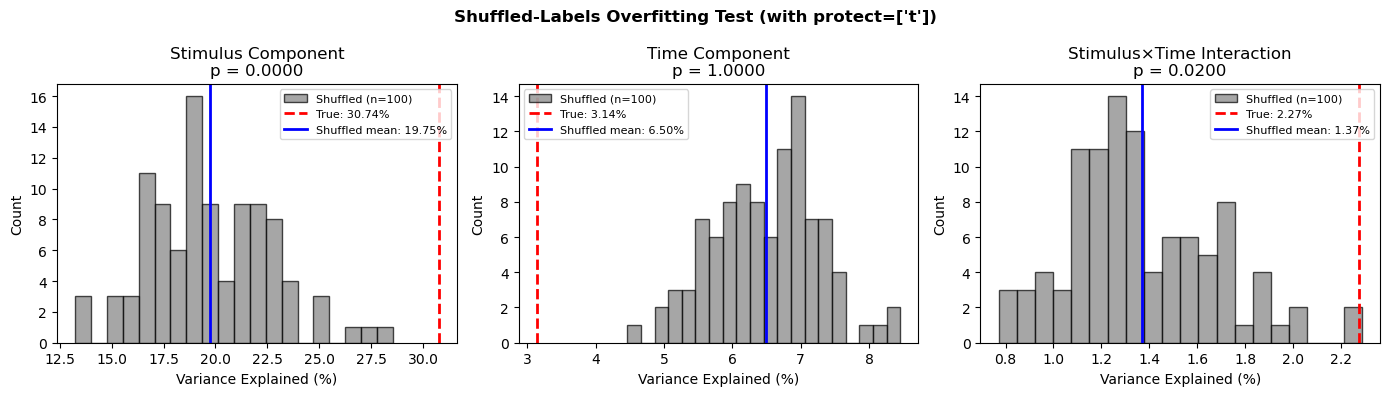


DETAILED STATISTICS:

Stimulus component:
  True variance: 30.742%
  Shuffled: mean=19.752%, std=2.958%
  Z-score: 3.72

Time component:
  True variance: 3.140%
  Shuffled: mean=6.496%, std=0.765%
  Z-score: -4.39


In [13]:
# Analyze and visualize shuffled vs true variance explained
import matplotlib.pyplot as plt

shuffled_var_s_arr = np.array(shuffled_var_s_list)
shuffled_var_t_arr = np.array(shuffled_var_t_list)
shuffled_var_st_arr = np.array(shuffled_var_st_list)

# Calculate p-values (proportion of shuffles >= true value)
p_value_s = np.mean(shuffled_var_s_arr >= true_var_s_total)
p_value_t = np.mean(shuffled_var_t_arr >= true_var_t_total)
p_value_st = np.mean(shuffled_var_st_arr >= true_var_st_total)

print("=" * 60)
print("SHUFFLED-LABELS OVERFITTING TEST RESULTS")
print("=" * 60)
print(f"\n{'Component':<15} {'True (%)':<12} {'Shuffled Mean (%)':<20} {'p-value':<10} {'Significant?'}")
print("-" * 60)
print(f"{'Stimulus (s)':<15} {true_var_s_total*100:>8.2f}     {np.mean(shuffled_var_s_arr)*100:>12.2f}         {p_value_s:<10.4f} {'YES ***' if p_value_s < 0.001 else 'YES **' if p_value_s < 0.01 else 'YES *' if p_value_s < 0.05 else 'NO'}")
print(f"{'Time (t)':<15} {true_var_t_total*100:>8.2f}     {np.mean(shuffled_var_t_arr)*100:>12.2f}         {p_value_t:<10.4f} {'YES ***' if p_value_t < 0.001 else 'YES **' if p_value_t < 0.01 else 'YES *' if p_value_t < 0.05 else 'NO'}")
print(f"{'Interaction (st)':<15} {true_var_st_total*100:>8.2f}     {np.mean(shuffled_var_st_arr)*100:>12.2f}         {p_value_st:<10.4f} {'YES ***' if p_value_st < 0.001 else 'YES **' if p_value_st < 0.01 else 'YES *' if p_value_st < 0.05 else 'NO'}")

print("\n" + "=" * 60)
print("INTERPRETATION:")
print("=" * 60)
if p_value_s < 0.05:
    print(f"✓ STIMULUS component is NOT overfitting (p={p_value_s:.4f})")
    print(f"  True variance ({true_var_s_total*100:.2f}%) >> shuffled mean ({np.mean(shuffled_var_s_arr)*100:.2f}%)")
else:
    print(f"✗ STIMULUS component may be OVERFITTING (p={p_value_s:.4f})")
    print(f"  True variance similar to shuffled null distribution")

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Stimulus component
ax = axes[0]
ax.hist(shuffled_var_s_arr * 100, bins=20, alpha=0.7, color='gray', 
        label=f'Shuffled (n={n_shuffles})', edgecolor='black')
ax.axvline(true_var_s_total * 100, color='red', linewidth=2, linestyle='--', 
           label=f'True: {true_var_s_total*100:.2f}%')
ax.axvline(np.mean(shuffled_var_s_arr) * 100, color='blue', linewidth=2, 
           label=f'Shuffled mean: {np.mean(shuffled_var_s_arr)*100:.2f}%')
ax.set_xlabel('Variance Explained (%)')
ax.set_ylabel('Count')
ax.set_title(f'Stimulus Component\np = {p_value_s:.4f}')
ax.legend(fontsize=8)

# Time component
ax = axes[1]
ax.hist(shuffled_var_t_arr * 100, bins=20, alpha=0.7, color='gray', 
        label=f'Shuffled (n={n_shuffles})', edgecolor='black')
ax.axvline(true_var_t_total * 100, color='red', linewidth=2, linestyle='--', 
           label=f'True: {true_var_t_total*100:.2f}%')
ax.axvline(np.mean(shuffled_var_t_arr) * 100, color='blue', linewidth=2, 
           label=f'Shuffled mean: {np.mean(shuffled_var_t_arr)*100:.2f}%')
ax.set_xlabel('Variance Explained (%)')
ax.set_ylabel('Count')
ax.set_title(f'Time Component\np = {p_value_t:.4f}')
ax.legend(fontsize=8)

# Interaction component
ax = axes[2]
ax.hist(shuffled_var_st_arr * 100, bins=20, alpha=0.7, color='gray', 
        label=f'Shuffled (n={n_shuffles})', edgecolor='black')
ax.axvline(true_var_st_total * 100, color='red', linewidth=2, linestyle='--', 
           label=f'True: {true_var_st_total*100:.2f}%')
ax.axvline(np.mean(shuffled_var_st_arr) * 100, color='blue', linewidth=2, 
           label=f'Shuffled mean: {np.mean(shuffled_var_st_arr)*100:.2f}%')
ax.set_xlabel('Variance Explained (%)')
ax.set_ylabel('Count')
ax.set_title(f'Stimulus×Time Interaction\np = {p_value_st:.4f}')
ax.legend(fontsize=8)

plt.suptitle('Shuffled-Labels Overfitting Test (with protect=[\'t\'])', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Additional summary statistics
print("\n" + "=" * 60)
print("DETAILED STATISTICS:")
print("=" * 60)
print(f"\nStimulus component:")
print(f"  True variance: {true_var_s_total*100:.3f}%")
print(f"  Shuffled: mean={np.mean(shuffled_var_s_arr)*100:.3f}%, std={np.std(shuffled_var_s_arr)*100:.3f}%")
print(f"  Z-score: {(true_var_s_total - np.mean(shuffled_var_s_arr)) / np.std(shuffled_var_s_arr):.2f}")

print(f"\nTime component:")
print(f"  True variance: {true_var_t_total*100:.3f}%")
print(f"  Shuffled: mean={np.mean(shuffled_var_t_arr)*100:.3f}%, std={np.std(shuffled_var_t_arr)*100:.3f}%")
print(f"  Z-score: {(true_var_t_total - np.mean(shuffled_var_t_arr)) / np.std(shuffled_var_t_arr):.2f}")